# DeepLoc 2.1 on ClinVar: subcellular localization variant effects

Loads the merged wild-type vs. mutant DeepLoc 2.1 predictions (`clinvar_deeploc_deltas_rbp.tsv`, built by `../12_variant_effect_prediction/localization_condensate/merge_deeploc_deltas.py`) and does a sanity check plus first-pass exploration.

**Data file is not checked into git** (~1.0GB). Regenerate it with the pipeline in `12_variant_effect_prediction/`, or pull it from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**How the numbers were made.** Each variant's protein-level mutant sequence was built from the wild-type protein and scored with DeepLoc 2.1 (ESM1b), the same as the wild-type protein. `DELTA_x = MUT_x - WT_x` for each of 10 compartment probabilities and 4 membrane-type probabilities. `WT_label`/`MUT_label` are DeepLoc's predicted (multi-label) localization strings; `label_changed` is 1 if they differ. Only missense, nonsense, and in-frame indel-type variants are included (frameshift and stop-loss variants need CDS-level handling and are not built yet).

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `deeploc_clinvar_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

LOCS = ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
        "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]
MEMB = ["Peripheral", "Transmembrane", "Lipid anchor", "Soluble"]
GENE, ID = "GeneSymbol", "VariationID"


## Load data

In [2]:
df = pd.read_csv("clinvar_deeploc_deltas_rbp.tsv", sep="\t")
print(f"{len(df):,} variant rows, {df[GENE].nunique():,} genes")
df.head()

380,253 variant rows, 2,046 genes


,VariationID,GeneID,GeneSymbol,accession,category,WT_label,MUT_label,label_changed,WT_Cytoplasm,WT_Nucleus,...,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome,DELTA_Peripheral,DELTA_Transmembrane,DELTA_Lipid anchor,DELTA_Soluble
0,41,284403,WDR62,NM_001083961.2,missense,Cytoplasm,Cytoplasm,0,0.6338,0.3927,...,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,42,284403,WDR62,NM_001083961.2,missense,Cytoplasm,Cytoplasm,0,0.6338,0.3927,...,0.0014,0.000,-0.0022,-0.0022,0.0043,-0.0041,0.0001,-0.0019,0.0018,0.0014
2,43,284403,WDR62,NM_001083961.2,nonsense,Cytoplasm,Cytoplasm,0,0.6338,0.3927,...,-0.0584,0.005,-0.0273,0.1887,0.0706,-0.1088,0.0130,-0.0908,-0.0521,0.0126
3,203,79650,USB1,NM_024598.4,missense,Cytoplasm|Nucleus,Cytoplasm|Nucleus,0,0.4732,0.7247,...,-0.0093,0.000,-0.0010,-0.0022,-0.0007,-0.0013,-0.0026,0.0017,-0.0025,0.0004
4,268,282996,RBM20,NM_001134363.3,missense,Nucleus,Nucleus,0,0.3280,0.9165,...,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Sanity check: well-known proteins (wild-type predicted localization)

Textbook localizations compared with the top wild-type probability. Mismatches are model behavior to keep in mind, not necessarily pipeline errors.

In [3]:
expected = {"TARDBP": "Nucleus", "MATR3": "Nucleus", "FUS": "Nucleus", "SRSF1": "Nucleus",
            "HNRNPA1": "Nucleus", "PABPC1": "Cytoplasm", "ELAVL1": "Nucleus",
            "G3BP1": "Cytoplasm", "DDX3X": "Cytoplasm"}
wt_cols = [f"WT_{c}" for c in LOCS]
for g, exp in expected.items():
    rows = df[df[GENE] == g]
    if rows.empty:
        print(f"{g:8s}: not in this table"); continue
    r = rows.iloc[0]
    top = r[wt_cols].astype(float).idxmax().replace("WT_", "")
    print(f"{g:8s} top={top:22s} labels={r['WT_label']:35s} expected={exp:15s} [{'OK' if top == exp or exp in r['WT_label'] else 'MISMATCH'}]")

TARDBP   top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
MATR3    top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
FUS      top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
SRSF1    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
HNRNPA1  top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
PABPC1   top=Cytoplasm              labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]
ELAVL1   top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
G3BP1    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]
DDX3X    top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Cytoplasm       [OK]


## Wild-type predicted localization labels (unique protein-transcript pairs)

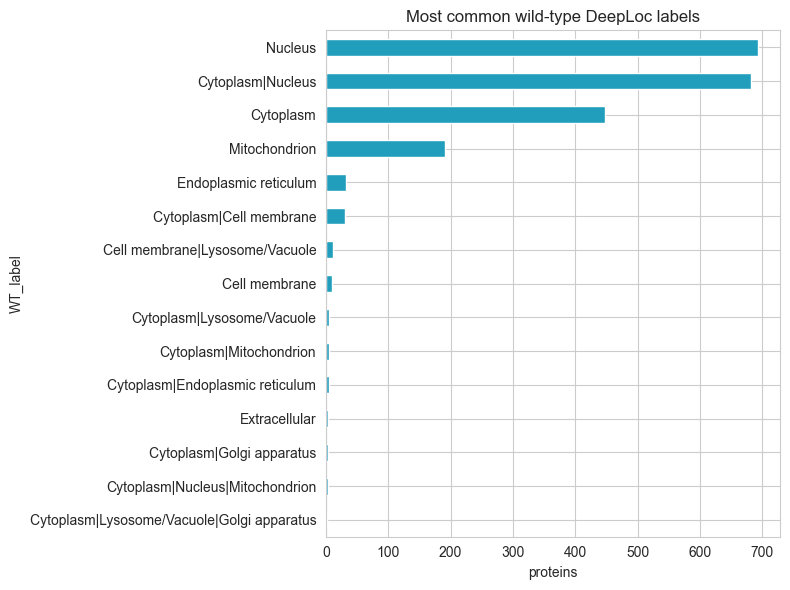

In [4]:
wt = df.drop_duplicates("accession")
top = wt["WT_label"].value_counts().head(15)
top.iloc[::-1].plot.barh(figsize=(8, 6), color="#219ebc")
plt.xlabel("proteins"); plt.title("Most common wild-type DeepLoc labels"); plt.tight_layout(); plt.show()

## How often does a variant change the predicted label?

In [5]:
print(f"Overall label_changed rate: {df['label_changed'].mean():.2%}")
by_cat = df.groupby("category")["label_changed"].agg(["mean", "size"]).sort_values("mean", ascending=False)
by_cat.rename(columns={"mean": "frac_label_changed", "size": "n"})

Overall label_changed rate: 1.75%


,frac_label_changed,n
category,,
nonsense,0.363193,14345
delins,0.126467,767
dup,0.012195,410
ins,0.010913,1008
del,0.006786,3684
missense,0.003650,360039


## How many variants change predicted localization?

Counts, then the fraction with a changed label broken down by variant category (missense, nonsense, etc.).

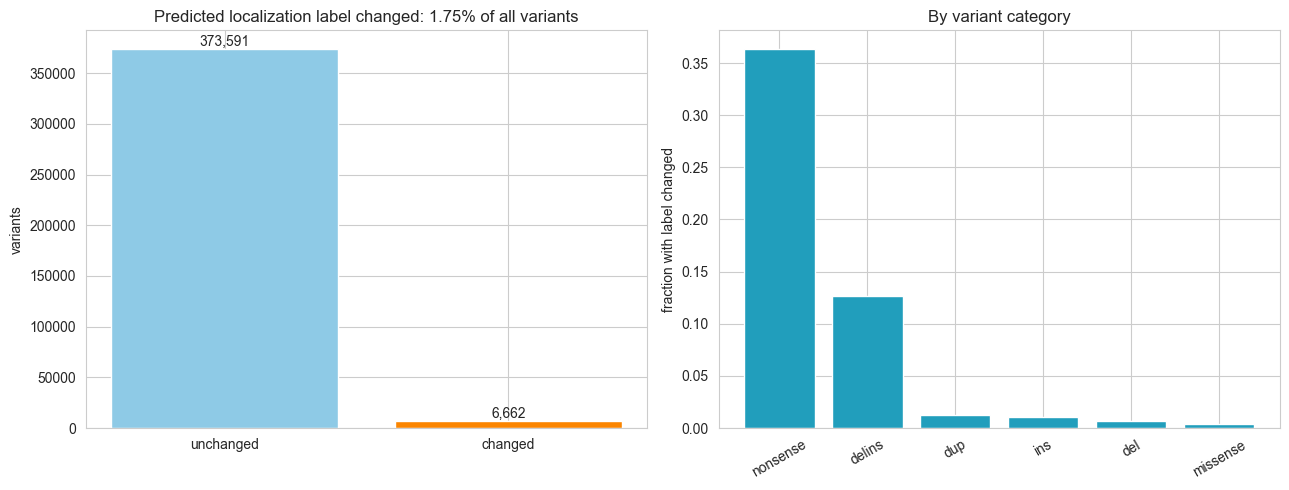

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["label_changed"].map({0: "unchanged", 1: "changed"}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[4]])
axes[0].set_ylabel("variants")
axes[0].set_title(f"Predicted localization label changed: {df['label_changed'].mean():.2%} of all variants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

by_cat = df.groupby("category")["label_changed"].mean().sort_values(ascending=False)
axes[1].bar(by_cat.index, by_cat.values, color=PALETTE[1])
axes[1].set_ylabel("fraction with label changed")
axes[1].set_title("By variant category")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

`DELTA = mutant - WT` probability. Most variants should sit near zero; the tails are the interesting cases (log y-axis).

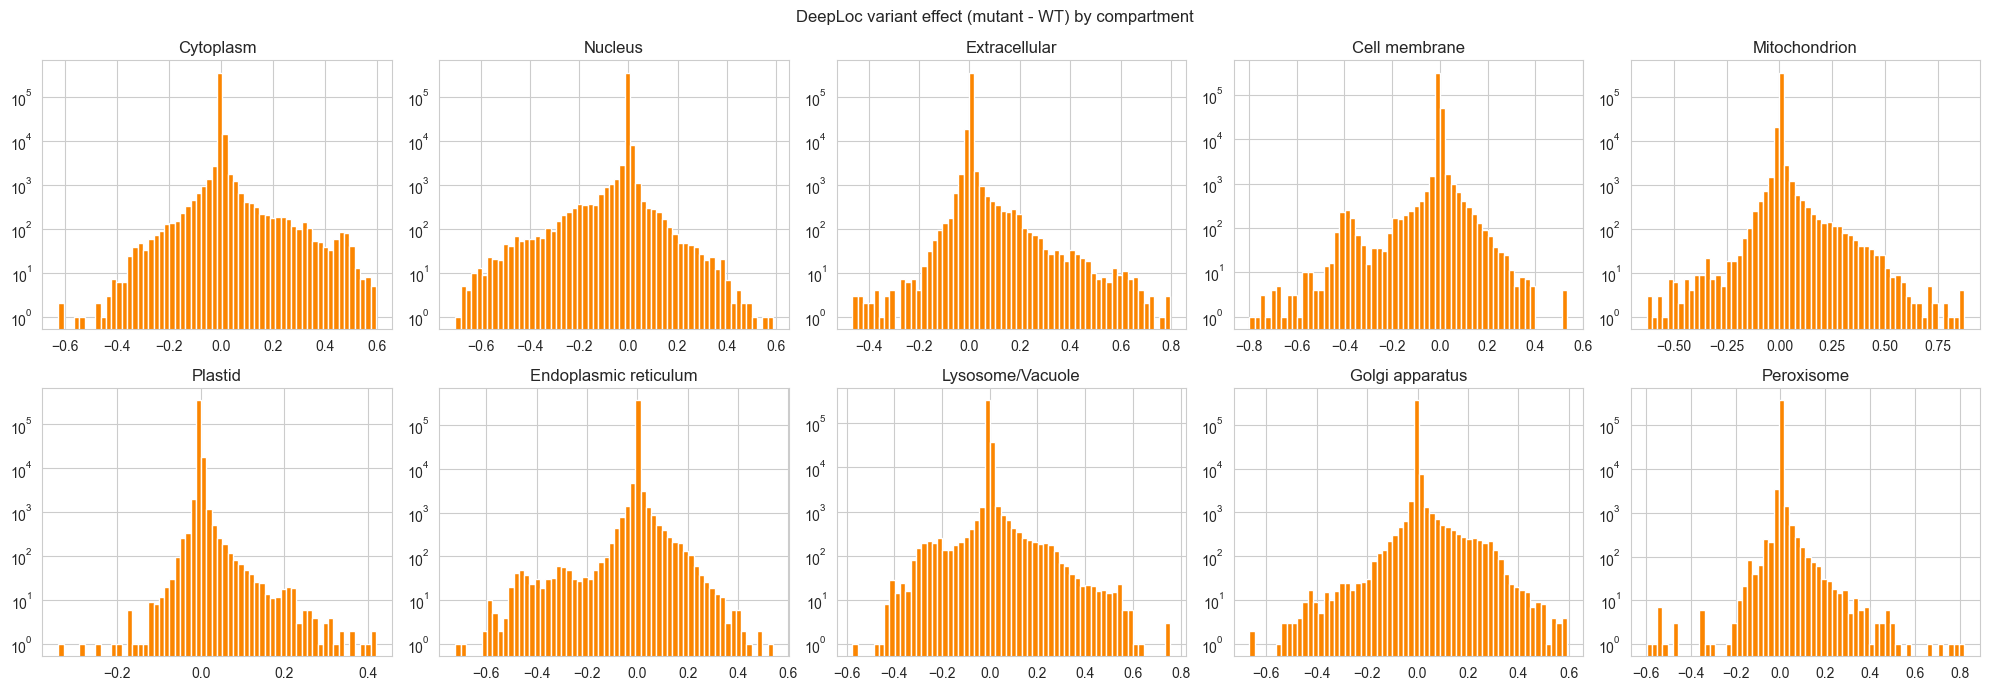

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.flat, LOCS):
    ax.hist(df[f"DELTA_{c}"], bins=60, color="#fb8500"); ax.set_yscale("log"); ax.set_title(c)
fig.suptitle("DeepLoc variant effect (mutant - WT) by compartment"); fig.tight_layout(); plt.show()

## Wild-type label to mutant label transitions

Among variants whose label changed: the most common transitions.

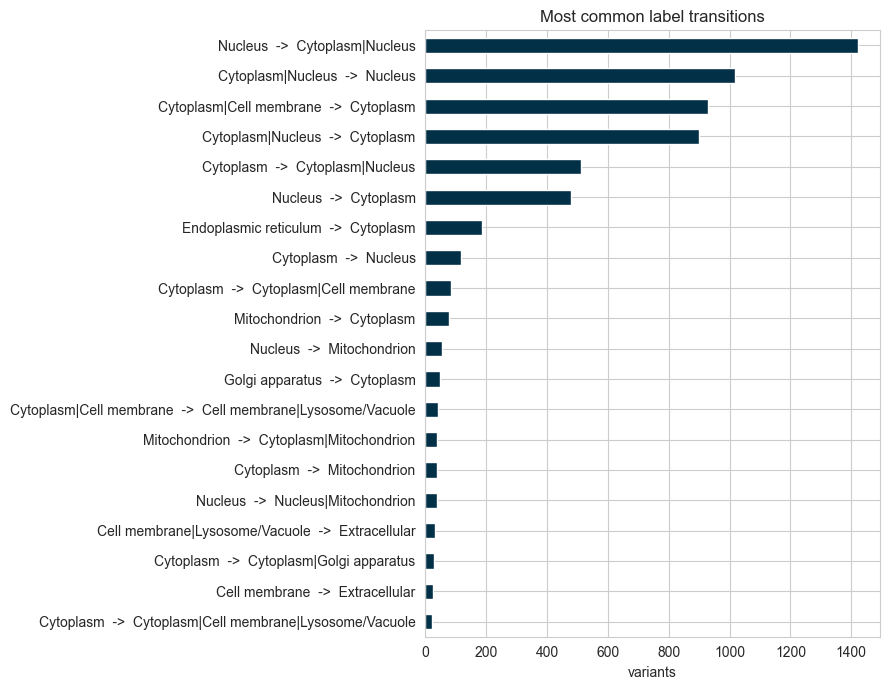

In [8]:
ch = df[df["label_changed"] == 1]
trans = (ch["WT_label"] + "  ->  " + ch["MUT_label"]).value_counts().head(20)
trans.iloc[::-1].plot.barh(figsize=(9, 7), color="#023047")
plt.xlabel("variants"); plt.title("Most common label transitions"); plt.tight_layout(); plt.show()

## Variants with the largest predicted localization shift

Ranked by the largest absolute delta across the 10 compartments.

In [9]:
dcols = [f"DELTA_{c}" for c in LOCS]
mx = df[dcols].abs().max(axis=1)
top = df.loc[mx.sort_values(ascending=False).index[:25]]
top[[ID, GENE, "category", "WT_label", "MUT_label"] + dcols]

,VariationID,GeneSymbol,category,WT_label,MUT_label,DELTA_Cytoplasm,DELTA_Nucleus,DELTA_Extracellular,DELTA_Cell membrane,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome
337534,4386975,BAZ2A,nonsense,Nucleus,Mitochondrion|Lysosome/Vacuole,0.2218,-0.6055,0.4745,0.0335,0.8759,0.0121,0.0214,0.5478,0.4805,0.0519
345176,4530615,PHIP,nonsense,Nucleus,Mitochondrion|Lysosome/Vacuole,0.2923,-0.6145,0.4642,0.0646,0.8670,-0.0032,0.0527,0.5400,0.4724,0.0519
340984,4467452,UPF3B,nonsense,Cytoplasm|Nucleus,Mitochondrion|Lysosome/Vacuole,-0.2668,-0.2458,0.3461,-0.1332,0.8593,0.0140,-0.0306,0.5396,0.4729,0.0539
340446,4472071,PHF6,nonsense,Nucleus,Mitochondrion|Lysosome/Vacuole,0.1778,-0.6207,0.4170,0.0592,0.8560,-0.0040,0.0687,0.5455,0.4426,0.0534
27754,568051,LMNA,nonsense,Cytoplasm|Nucleus,Mitochondrion|Lysosome/Vacuole,-0.1172,-0.3791,0.4249,-0.0723,0.8406,0.0141,0.0094,0.4459,0.3338,0.0406
291780,3913780,MSH6,nonsense,Nucleus,Mitochondrion|Lysosome/Vacuole,0.1922,-0.6163,0.4723,0.0617,0.8210,0.0058,0.0482,0.5498,0.4978,0.0464
339015,4423304,PELP1,nonsense,Nucleus,Cytoplasm|Peroxisome,0.2214,-0.5870,0.3421,0.1399,0.2738,0.0802,0.2294,0.3107,0.1510,0.8192
365246,4716774,EPHB4,nonsense,Cell membrane|Lysosome/Vacuole,Nucleus,0.1676,0.3749,0.1313,-0.7985,0.4242,0.0239,0.1638,-0.2280,-0.0467,0.1980
47828,872391,DSG1,nonsense,Cell membrane,Extracellular,-0.0750,-0.0266,0.7945,-0.6694,0.0261,0.0284,-0.0405,-0.1432,-0.0449,-0.0293
191229,2764098,DSG1,nonsense,Cell membrane,Extracellular,-0.0649,-0.0051,0.7902,-0.6788,0.0320,0.0347,-0.0389,-0.1324,-0.0535,-0.0279


## Genes with the most variants that shift localization

Counted as variants with any compartment delta of at least 0.5 in magnitude.

In [10]:
big = df[mx >= 0.5]
print(f"{len(big):,} variants ({len(big)/len(df):.2%}) with |delta| >= 0.5")
big[GENE].value_counts().head(20)

446 variants (0.12%) with |delta| >= 0.5


GeneSymbol
SYNE2      30
EPHB4      29
SYNE1      22
TRIO       17
PHIP       15
LEMD3      14
DSG1       13
DDX3X       9
TBL1XR1     9
RECQL       7
TOP3A       7
MSH6        7
BRIP1       7
DMD         6
RAD50       6
RTEL1       5
ELAC2       5
KMT2A       5
CDC73       5
APC         5
Name: count, dtype: int64

## ClinVar clinical significance vs. predicted localization change

Joins ClinicalSignificance from `clinvar_metadata_lookup_rbp.tsv`. If localization changes are functionally meaningful, pathogenic variants should shift more than benign ones.

In [11]:
meta = pd.read_csv("clinvar_metadata_lookup_rbp.tsv", sep="\t", usecols=["VariationID", "ClinicalSignificance"]).drop_duplicates("VariationID")
m = df.merge(meta, on="VariationID", how="left")
m["max_abs_delta"] = m[dcols].abs().max(axis=1)
groups = ["Pathogenic", "Likely pathogenic", "Uncertain significance", "Likely benign", "Benign"]
s = m[m["ClinicalSignificance"].isin(groups)]
summary = s.groupby("ClinicalSignificance").agg(n=("max_abs_delta", "size"), label_changed=("label_changed", "mean"),
                                                 median_max_delta=("max_abs_delta", "median"),
                                                 frac_delta_ge_0_5=("max_abs_delta", lambda x: (x >= 0.5).mean())).loc[groups]
summary

,n,label_changed,median_max_delta,frac_delta_ge_0_5
ClinicalSignificance,,,,
Pathogenic,9916,0.293969,0.1065,0.020069
Likely pathogenic,5741,0.134820,0.0051,0.012193
Uncertain significance,313683,0.005588,0.0016,0.000201
Likely benign,14382,0.003407,0.0010,0.000000
Benign,4228,0.002129,0.0008,0.000237


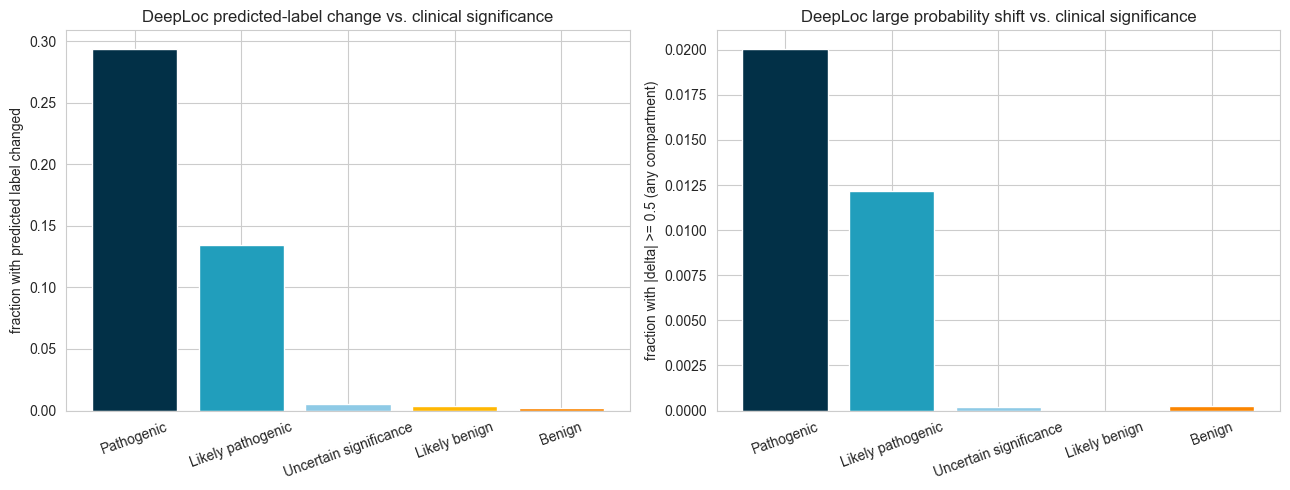

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [PALETTE[2], PALETTE[1], PALETTE[0], PALETTE[3], PALETTE[4]]
axes[0].bar(summary.index, summary["label_changed"], color=colors)
axes[0].set_ylabel("fraction with predicted label changed")
axes[0].set_title("DeepLoc predicted-label change vs. clinical significance")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary.index, summary["frac_delta_ge_0_5"], color=colors)
axes[1].set_ylabel("fraction with |delta| >= 0.5 (any compartment)")
axes[1].set_title("DeepLoc large probability shift vs. clinical significance")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

/var/folders/pf/8s82tkcj2z92hkmhf8vknhh80000gn/T/ipykernel_2872/496002890.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="ClinicalSignificance", y="max_abs_delta", order=groups, showfliers=False, palette=PALETTE)


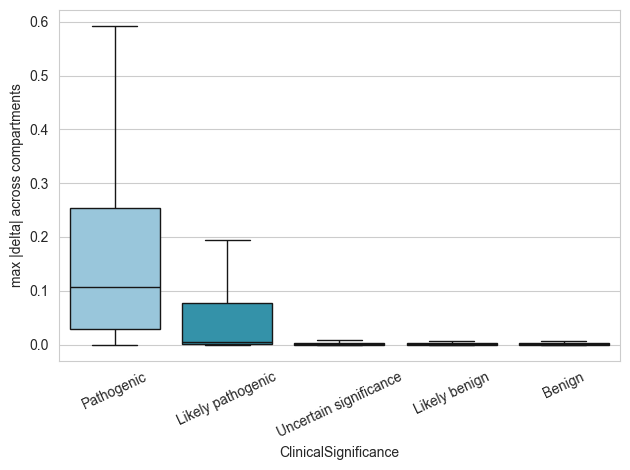

In [13]:
sns.boxplot(data=s, x="ClinicalSignificance", y="max_abs_delta", order=groups, showfliers=False, palette=PALETTE)
plt.xticks(rotation=25); plt.ylabel("max |delta| across compartments"); plt.tight_layout(); plt.show()